# 02 - Convolutional VAE

Learns a 16-dimensional summary of each daily scalogram (128 scales x 24 hours). A Gaussian mixture on those summaries assigns each day to a market regime.

Pipeline: scalogram -> ConvVAE encoder -> latent mean (mu) + daily price level -> GMM -> regime

Methodology notes:
1. Days are split chronologically (60% train, 20% validation, 20% test). The 2023-2024 El Niño falls in the test period.
2. The GMM is fitted on training days only and then applied to all days.
3. Scalograms come from the log real price with each day's mean removed, so they show only the intraday shape. The daily level is added to the latent vector before the GMM.

<d.benavidess@uniandes.edu.co>

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch

import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

plt.rcParams['font.family'] = 'Arial'
alt.data_transformers.enable('vegafusion')

from src.data import load_scalograms, load_context, chronological_split, ScalogramDataset
from src.models.conv_vae import ConvVAE
from src.training import set_seed, train, save_run
from src.clustering import with_level, assign_regimes, summary_metrics, regime_profile, save_regimes
from src.plots import loss_curves, selection_chart, tsne_chart, regime_timeline, plot_reconstructions

In [2]:
import warnings
warnings.filterwarnings("ignore")

## 0. Experiment Run

In [3]:
# Update the run name to reflect the current experiment
# Update 1. Configuration / CONFIG n_regimes
RUN_NAME = "run01_k8"
n_regimes = 8

## 1. Configuration

In [4]:
SCALOGRAM_DIR = Path("../data/processed/scalograms")
DATA_DIR = Path("../data/processed")
MODEL_DIR = Path("../models/vae") / RUN_NAME
FIGURE_DIR = Path("../figures/vae") / RUN_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "z_dim": 16,
    "filters": [32, 64, 128],
    "beta": 1.0,
    "kl_warmup_epochs": 0,
    "lr": 1e-3,
    "batch_size": 64,
    "epochs": 30,
    "train_ratio": 0.6,
    "val_ratio": 0.2,
    "n_regimes": n_regimes,
    "k_range": [2, 3, 4, 5, 6, 7, 8],
    "seed": 42,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(CONFIG["seed"])
print(f"Device: {DEVICE}")

Device: cpu


## 2. Data

In [5]:
images, metadata = load_scalograms(SCALOGRAM_DIR)
context = load_context(DATA_DIR, metadata)
train_idx, val_idx, test_idx = chronological_split(len(images), CONFIG["train_ratio"], CONFIG["val_ratio"])
split_dates = [context["date"].iloc[val_idx[0]], context["date"].iloc[test_idx[0]]]

IMG_C, IMG_H, IMG_W = images.shape[1:]
print(f"Scalograms: {images.shape}, range [{images.min():.3f}, {images.max():.3f}]")

t = PrettyTable(["Split", "Days", "From", "To"])
for name, idx in (("train", train_idx), ("val", val_idx), ("test", test_idx)):
    t.add_row([name, len(idx), context["date"].iloc[idx[0]].date(), context["date"].iloc[idx[-1]].date()])
print(t)

Scalograms: (9709, 1, 128, 24), range [0.000, 1.000]
+-------+------+------------+------------+
| Split | Days |    From    |     To     |
+-------+------+------------+------------+
| train | 5825 | 2000-01-01 | 2015-12-12 |
|  val  | 1942 | 2015-12-13 | 2021-04-06 |
|  test | 1942 | 2021-04-07 | 2026-07-31 |
+-------+------+------------+------------+


In [6]:
train_loader = DataLoader(ScalogramDataset(images, train_idx), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(ScalogramDataset(images, val_idx), batch_size=CONFIG["batch_size"], shuffle=False)

## 3. Model

In [7]:
model = ConvVAE(CONFIG["z_dim"], IMG_C, IMG_H, IMG_W, CONFIG["filters"]).to(DEVICE)

with torch.no_grad():
    out_shape = tuple(model(torch.from_numpy(images[:2]).to(DEVICE))[0].shape[1:])
assert out_shape == (IMG_C, IMG_H, IMG_W), f"decoder output {out_shape} does not match input"

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Encoder feature map: {model.encoder.feat_shape}")
print(f"Decoder output: {out_shape}")

Parameters: 486,945
Encoder feature map: (128, 16, 3)
Decoder output: (1, 128, 24)


## 4. Training

In [8]:
history = train(model, train_loader, val_loader, DEVICE, epochs=CONFIG["epochs"], lr=CONFIG["lr"],
                beta=CONFIG["beta"], kl_warmup_epochs=CONFIG["kl_warmup_epochs"])
save_run(MODEL_DIR, model, CONFIG, history)

Epoch   1/30  train: total=1402.49  recon=1374.05  kl=28.44  val total=1077.76
Epoch   5/30  train: total=988.21  recon=975.35  kl=12.86  val total=1013.65
Epoch  10/30  train: total=983.11  recon=973.69  kl=9.42  val total=1001.74
Epoch  15/30  train: total=993.90  recon=980.89  kl=13.02  val total=1008.80
Epoch  20/30  train: total=972.76  recon=965.83  kl=6.93  val total=1000.45
Epoch  25/30  train: total=987.39  recon=980.59  kl=6.80  val total=1015.00
Epoch  30/30  train: total=972.36  recon=965.15  kl=7.20  val total=1004.20


## 5. Loss curves

Posterior collapse check: if the KL curve drops close to zero, the encoder is ignoring the input. In that case try `beta` below 1 or set `kl_warmup_epochs` (for example 10). Active dimensions counts the latent dimensions whose mean actually varies across days.

In [9]:
loss_plot = loss_curves(history, components=("total", "recon", "kl"))
loss_plot

alt.HConcatChart(...)

In [10]:
loss_plot.save(str(FIGURE_DIR / "loss_curves.png"), scale_factor=2.0)

## 6. Reconstructions

Test-period days.

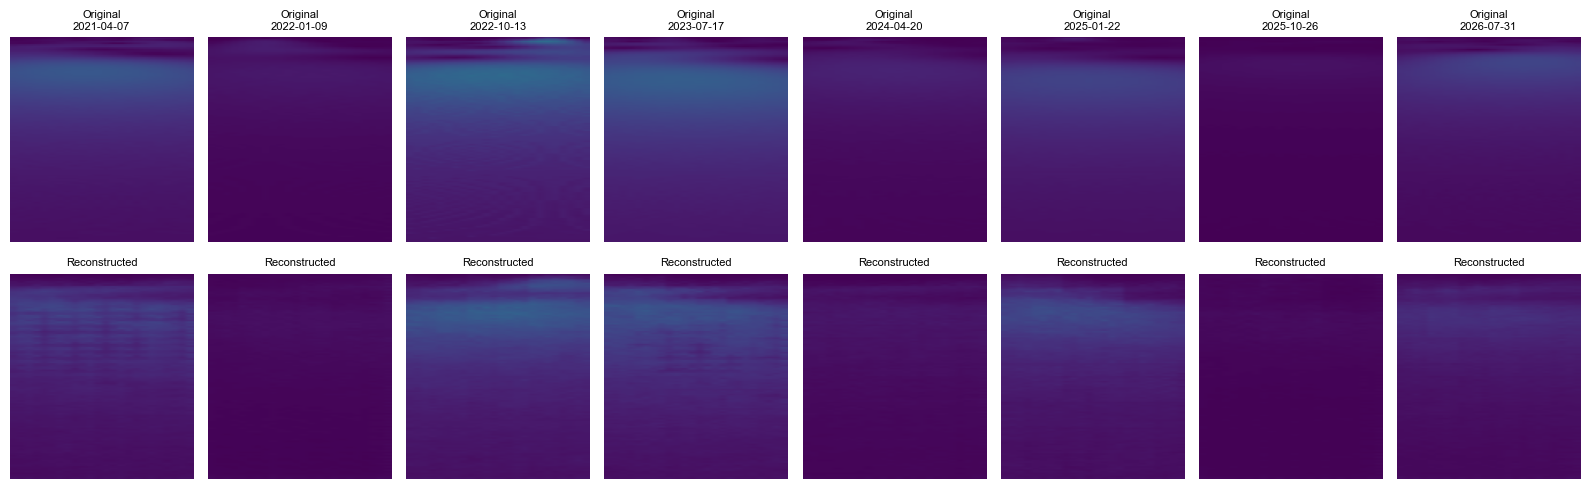

In [11]:
model.eval()
show_idx = test_idx[np.linspace(0, len(test_idx) - 1, 8).astype(int)]
with torch.no_grad():
    recon = model(torch.from_numpy(images[show_idx]).to(DEVICE))[0].cpu().numpy()

fig = plot_reconstructions(images[show_idx], recon, [str(d.date()) for d in context["date"].iloc[show_idx]])
fig.savefig(FIGURE_DIR / "reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Latent vectors

In [12]:
latents = model.extract_latents(images, DEVICE)

np.save(MODEL_DIR / "latents.npy", latents)
features = with_level(latents, metadata, train_idx)

active = int((latents.var(axis=0) > 0.01).sum())
print(f"Latent vectors: {latents.shape}")
print(f"Final train KL: {history[-1]['train_kl']:.2f}")
print(f"Active dimensions: {active} of {CONFIG['z_dim']}")
print(f"GMM features (latents + daily level): {features.shape}")

Latent vectors: (9709, 16)
Final train KL: 7.20
Active dimensions: 15 of 16
GMM features (latents + daily level): (9709, 18)


## 8. Regimes with a Gaussian mixture

The GMM uses the latent vector plus the daily price level (mean and standard deviation of the log real price, z-scored on training days), because the scalograms only carry the intraday shape. It is fitted on the training days only and then assigns every day. The number of regimes is the one with the lowest BIC unless `CONFIG["n_regimes"]` fixes it. Regimes are numbered by ascending mean real price, so regime 0 is always the cheapest and labels are comparable across models.

In [13]:
selection, K, labels, probs = assign_regimes(
    features, train_idx, context["precio_real_cop_kwh"].to_numpy(),
    k=CONFIG["n_regimes"], k_range=CONFIG["k_range"], seed=CONFIG["seed"],
)
context["regime"] = labels

t = PrettyTable(["k", "BIC", "Silhouette"])
for _, row in selection.iterrows():
    t.add_row([int(row["k"]), f"{row['bic']:,.0f}", f"{row['silhouette']:.3f}"])
print(t)
print(f"Selected k = {K}")
if CONFIG["n_regimes"] is None and K == max(CONFIG["k_range"]):
    print("BIC is still falling at the largest k. Choose k from the table and set CONFIG['n_regimes'] by hand.")

  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


+---+----------+------------+
| k |   BIC    | Silhouette |
+---+----------+------------+
| 2 | -195,454 |   0.302    |
| 3 | -231,292 |   0.201    |
| 4 | -245,743 |   0.179    |
| 5 | -256,795 |   0.177    |
| 6 | -266,045 |   0.143    |
| 7 | -273,482 |   0.156    |
| 8 | -276,443 |   0.152    |
+---+----------+------------+
Selected k = 8


In [14]:
selection_plot = selection_chart(selection, K)
selection_plot

alt.HConcatChart(...)

In [15]:
selection_plot.save(str(FIGURE_DIR / "gmm_selection.png"), scale_factor=2.0)

## 9. Latent space

In [16]:
rng = np.random.default_rng(CONFIG["seed"])
plot_idx = np.sort(rng.choice(len(features), size=min(5000, len(features)), replace=False))
coords = TSNE(n_components=2, perplexity=30, random_state=CONFIG["seed"]).fit_transform(features[plot_idx])

tsne_plot = tsne_chart(coords, labels[plot_idx], f"t-SNE of the latent space (k={K})")
tsne_plot

alt.Chart(...)

In [17]:
tsne_plot.save(str(FIGURE_DIR / "tsne_regimes.png"), scale_factor=2.0)

## 10. Regime timeline

Shaded bands are El Nino months (ONI >= 0.5). Dashed lines mark the start of the validation and test periods. First sanity check: the high-price regimes should concentrate in the 2015-2016 and 2023-2024 El Nino episodes and in low reservoir periods.

In [18]:
timeline_plot = regime_timeline(context, split_dates, title=f"Detected regimes over time (k={K})")
timeline_plot

alt.VConcatChart(...)

In [19]:
timeline_plot.save(str(FIGURE_DIR / "regime_timeline.png"), scale_factor=2.0)

In [20]:
profile = regime_profile(context)
t = PrettyTable(["Regime", "Days", "Share %", "Real price", "Reservoir", "Mean ONI", "El Nino %"])
for _, row in profile.iterrows():
    t.add_row([int(row["regime"]), int(row["days"]), f"{row['share_pct']:.1f}", f"{row['mean_real_price']:.1f}",
               f"{row['mean_reservoir']:.3f}", f"{row['mean_oni']:.2f}", f"{row['el_nino_pct']:.1f}"])
print(t)

+--------+------+---------+------------+-----------+----------+-----------+
| Regime | Days | Share % | Real price | Reservoir | Mean ONI | El Nino % |
+--------+------+---------+------------+-----------+----------+-----------+
|   0    | 906  |   9.3   |   219.4    |   0.695   |  -0.11   |    19.4   |
|   1    | 507  |   5.2   |   282.3    |   0.727   |  -0.27   |    13.2   |
|   2    | 1025 |   10.6  |   287.1    |   0.706   |  -0.10   |    17.5   |
|   3    | 718  |   7.4   |   316.6    |   0.712   |  -0.14   |    18.5   |
|   4    | 949  |   9.8   |   317.7    |   0.672   |  -0.07   |    21.8   |
|   5    | 1854 |   19.1  |   330.7    |   0.655   |   0.04   |    27.2   |
|   6    | 2303 |   23.7  |   330.9    |   0.678   |   0.13   |    28.7   |
|   7    | 1447 |   14.9  |   365.4    |   0.650   |   0.10   |    32.9   |
+--------+------+---------+------------+-----------+----------+-----------+


In [21]:
metrics = {"model": "conv_vae", "k": K, **summary_metrics(features, labels, seed=CONFIG["seed"])}
save_regimes(MODEL_DIR, context, labels, probs, metrics)

t = PrettyTable(["Metric", "Value"])
for key, value in metrics.items():
    t.add_row([key, f"{value:.3f}" if isinstance(value, float) else value])
print(t)

+-------------------+----------+
|       Metric      |  Value   |
+-------------------+----------+
|       model       | conv_vae |
|         k         |    8     |
|      regimes      |    8     |
|     silhouette    |  0.112   |
|   mean_run_days   |  1.637   |
|  median_run_days  |  1.000   |
| switches_per_year | 223.047  |
+-------------------+----------+


In [22]:
spread = context.groupby("regime")["precio_real_cop_kwh"].describe(percentiles=[0.1, 0.5, 0.9])
spread[["count", "10%", "50%", "90%", "min", "max"]].round(1)

,count,10%,50%,90%,min,max
regime,,,,,,
0,906.0,126.5,194.1,335.8,81.7,1356.9
1,507.0,132.6,187.3,529.7,94.1,3180.9
2,1025.0,130.6,212.4,493.0,85.6,2298.6
3,718.0,155.4,234.7,559.7,112.8,2560.4
4,949.0,145.4,238.2,579.3,104.6,3410.9
5,1854.0,145.8,251.2,612.4,79.9,3435.3
6,2303.0,120.5,217.8,709.4,76.1,3582.7
7,1447.0,162.2,299.4,631.1,91.2,3471.0


In [23]:
from src.clustering import fit_gmm, order_regimes

price = context["precio_real_cop_kwh"].to_numpy()
level = with_level(np.zeros((len(latents), 0)), metadata, train_idx)
smooth = pd.DataFrame(latents).rolling(7, min_periods=1).mean().to_numpy()

t = PrettyTable(["Features", "Silhouette", "Mean run", "Switches / yr", "Median price by regime"])
for name, f in (("level only", level), ("latents only", latents),
                ("latents + level", features), ("7d-mean latents + level", with_level(smooth, metadata, train_idx))):
    lab = order_regimes(fit_gmm(f, train_idx, 4, CONFIG["seed"])[0], price)
    m = summary_metrics(f, lab, seed=CONFIG["seed"])
    med = context.assign(r=lab).groupby("r")["precio_real_cop_kwh"].median().round(0).tolist()
    t.add_row([name, f"{m['silhouette']:.3f}", f"{m['mean_run_days']:.1f}", f"{m['switches_per_year']:.0f}", med])
print(t)
print(pd.crosstab(labels, context["date"].dt.dayofweek, normalize="columns").mul(100).round(0))

+-------------------------+------------+----------+---------------+------------------------------+
|         Features        | Silhouette | Mean run | Switches / yr |    Median price by regime    |
+-------------------------+------------+----------+---------------+------------------------------+
|        level only       |   0.236    |   3.2    |      115      | [167.0, 206.0, 284.0, 704.0] |
|       latents only      |   0.180    |   2.1    |      171      | [223.0, 242.0, 235.0, 225.0] |
|     latents + level     |   0.144    |   2.1    |      171      | [223.0, 245.0, 231.0, 224.0] |
| 7d-mean latents + level |   0.105    |   8.1    |       45      | [172.0, 226.0, 226.0, 313.0] |
+-------------------------+------------+----------+---------------+------------------------------+
date      0     1     2     3     4     5     6
row_0                                          
0       9.0  10.0  10.0   9.0   8.0   8.0  11.0
1       4.0   4.0   5.0   5.0   5.0   7.0   7.0
2      11.0  13.

In [25]:
print("Latent variance per dim:", np.round(latents.var(axis=0), 5))
print("Latent std range:", latents.std(axis=0).min().round(4), "to", latents.std(axis=0).max().round(4))

Latent variance per dim: [0.12624 0.07481 0.0367  0.09515 0.06898 0.00558 0.53711 1.25712 1.3881
 0.07015 0.03287 0.09332 2.38617 0.02783 0.66348 0.03003]
Latent std range: 0.0747 to 1.5447
